<h1>Initialization</h1>

In [313]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

<h1>Data Collection</h1>

In [314]:
df = pd.read_csv(filepath_or_buffer="./housing.csv")

<h1>EDA</h1>

In [315]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [316]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [317]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [318]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [319]:
df.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

<h1>Preprocessing</h1>

In [320]:
proximity = pd.get_dummies(data=df.ocean_proximity, drop_first=True)
proximity = proximity.astype(int)
proximity

,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0
...,...,...,...,...
20635,1,0,0,0
20636,1,0,0,0
20637,1,0,0,0
20638,1,0,0,0


In [321]:
df = pd.concat(objs=[df, proximity], axis=1)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,1,0,0,0


In [322]:
df = df.drop(["ocean_proximity"], axis=1)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,0,0,0


In [323]:
imputer = SimpleImputer(strategy="median")
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
INLAND                0
ISLAND                0
NEAR BAY              0
NEAR OCEAN            0
dtype: int64

<h1>Analyse</h1>

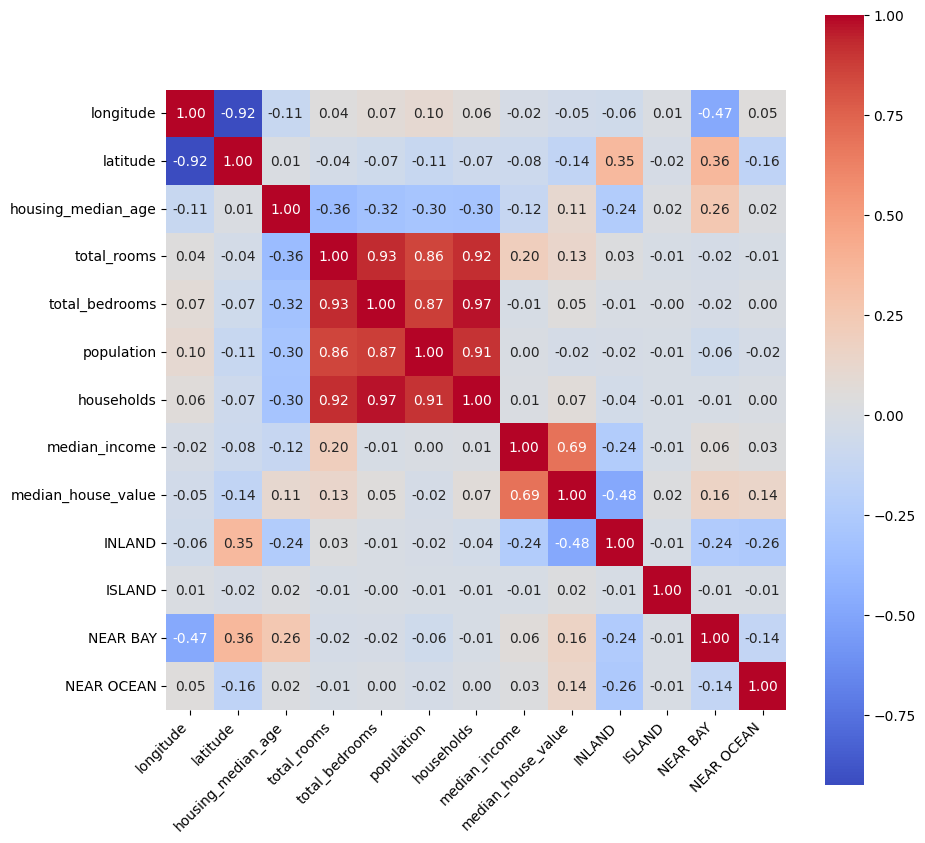

In [324]:
correlated_df = df.corr()

plt.figure(figsize=(10,10))
sns.heatmap(correlated_df, square=True,
            annot=True, annot_kws={"size": 10},
            fmt="0.2f", cmap="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.show()

<h1>SLR</h1>

In [325]:
SLR_X = df[["median_income"]]
SLR_Y = df.median_house_value

In [326]:
X_train_SLR, X_test_SLR, Y_train_SLR, Y_test_SLR = train_test_split(SLR_X, SLR_Y, random_state=42, test_size=0.25)

SLR = LinearRegression()
SLR.fit(X_train_SLR, Y_train_SLR)

LinearRegression()

In [327]:
SLR_predictions = SLR.predict(X_test_SLR)
SLR_predictions

array([115221.69603557, 150745.74877985, 190394.28570936, ...,
       135509.81226584, 332757.94044318, 322110.3358799 ])

In [328]:
print(f"R^2= {metrics.r2_score(Y_test_SLR, SLR_predictions)}")
print(f"MSE= {metrics.mean_squared_error(Y_test_SLR, SLR_predictions)}")
print(f"RMSE= {metrics.root_mean_squared_error(Y_test_SLR, SLR_predictions)}")

R^2= 0.47083837938023365
MSE= 7001962368.292409
RMSE= 83677.72922523895


<h1>MLR</h1>

In [329]:
MLR_X = df.drop(axis=1, labels="median_house_value")
MLR_Y = df["median_house_value"]

In [330]:
X_train_MLR, X_test_MLR, Y_train_MLR, Y_test_MLR = train_test_split(MLR_X, MLR_Y, random_state=42, test_size=0.25)

MLR = LinearRegression()
MLR.fit(X_train_MLR, Y_train_MLR)

LinearRegression()

In [331]:
MLR_predictions = MLR.predict(X_test_MLR)
MLR_predictions

array([ 54598.80242213, 123651.25890837, 252632.35704978, ...,
       140614.11326653, 243327.82857325, 350156.23528829])

In [332]:
print(f"R^2= {metrics.r2_score(Y_test_MLR, MLR_predictions)}")
print(f"MSE= {metrics.mean_squared_error(Y_test_MLR, MLR_predictions)}")
print(f"RMSE= {metrics.root_mean_squared_error(Y_test_MLR, MLR_predictions)}")

R^2= 0.6374825568355218
MSE= 4796896441.420494
RMSE= 69259.63067632179


<h1>Comparasion</h1>

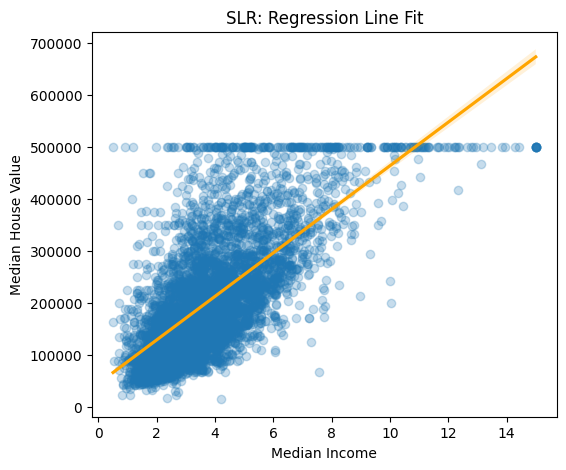

In [333]:
plt.figure(figsize=(6,5))

sns.regplot(
    x=X_test_SLR["median_income"],
    y=Y_test_SLR,
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "orange"}
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("SLR: Regression Line Fit")
plt.show()

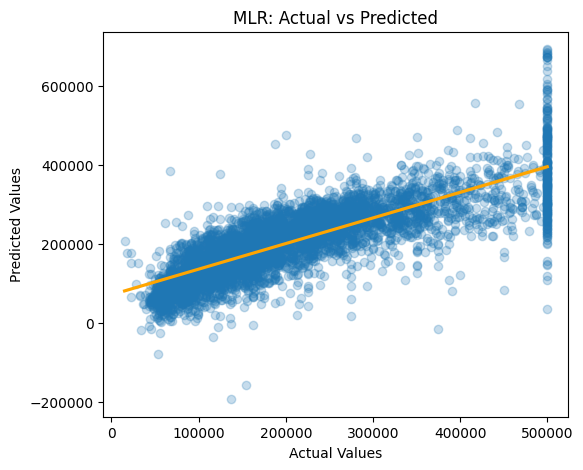

In [334]:
plt.figure(figsize=(6,5))

sns.regplot(
    x=Y_test_MLR,
    y=MLR_predictions,
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "orange"}
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("MLR: Actual vs Predicted")
plt.show()

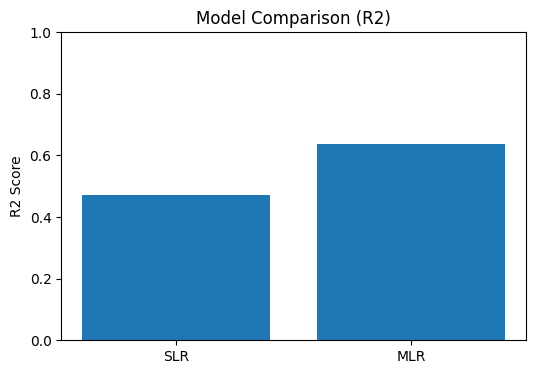

In [335]:
plt.figure(figsize=(6,4))

plt.bar(["SLR", "MLR"],
    [metrics.r2_score(Y_test_SLR, SLR_predictions),
    metrics.r2_score(Y_test_MLR, MLR_predictions)])

plt.ylabel("R2 Score")
plt.title("Model Comparison (R2)")
plt.ylim(0, 1)
plt.show()